# NLP : Data preprocessing and exploration

## Introduction

The goal of this notebook is to predict the wine quality based on its physicochemicals properties.

The dataset used contains data concerning the quality of the wine, which can be downloaded at the following link : https://archive.ics.uci.edu/dataset/186/wine+quality

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\emili\AppData\Roaming\Python\Python310\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Loading data and exploration


In [24]:
# Load the dataset
df = pd.read_csv("winequality.csv")

print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4      5.0  
1      9.8      5.0  
2      9.8      5.0 

## Preprocessing



In [25]:
# Check for missing values
print(df.isnull().sum())

# Impute missing values with the mean
df.fillna(df.mean(), inplace=True)

# Verify that there are no more missing values
print(df.isnull().sum())

fixed acidity           73
volatile acidity        94
citric acid             79
residual sugar          79
chlorides               62
free sulfur dioxide     69
total sulfur dioxide    76
density                 84
pH                      94
sulphates               97
alcohol                 64
quality                 83
dtype: int64
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [26]:
# Examine the statistical summary of the features
print(df.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.320183          0.526648     0.271336        2.542105   
std         1.691527          0.172716     0.189322        1.391232   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.200000          0.400000     0.100000        1.900000   
50%         8.000000          0.526648     0.270000        2.200000   
75%         9.100000          0.630000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087310            15.884967             46.896257     0.996745   
std       0.046136            10.287779             32.145059     0.001857   
min       0.012000             1.000000         

### Outliers

Outliers are data points that differs significantly from other observations. They may be due to variability in the measurement, an indication of novel data, or it may be the result of experimental error. These extreme values can distord the estimated statistics and lead to incorrect statistical inferences. If outliers are found, I will remove them from the dataset.

#### Observations
These following characteristics seem to have outliers :
- "residual sugar"
- "citric acid"

I am going to create a boxplot to observe their data distribution.

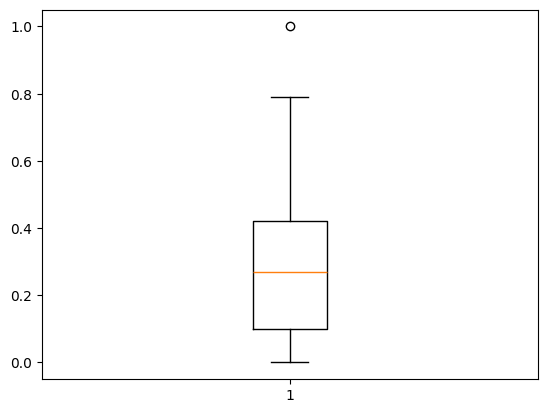

In [27]:
# Create a box plot of the "total sulfur dioxide" feature
#plt.boxplot(df["residual sugar"])
#plt.show()

plt.boxplot(df["citric acid"])
plt.show()

We can observe that there is 2 data points in "total sulfur dioxide" that difffer from the rest.

### Handle outliers : IQR method

The Interquartile Range (IQR) method is used for identifying outliers. This technique is robust as it is not easily swayed by extreme values it's trying to find, it relies on the spread of the middle 50% of the data. 

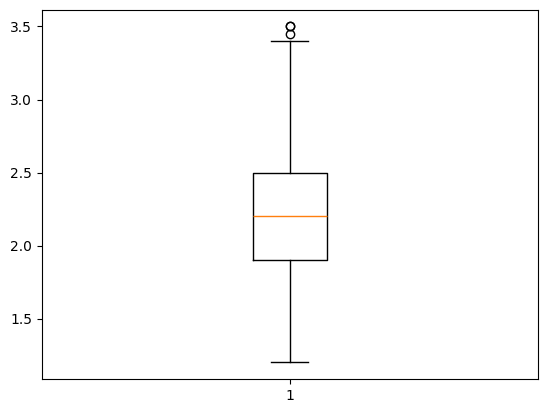

In [18]:
# Calculate the IQR for the "total sulfur dioxide" feature
Q1 = df["residual sugar"].quantile(0.25)
Q3 = df["residual sugar"].quantile(0.75)
IQR = Q3 - Q1
# Remove aberrant data points
df = df[~((df["residual sugar"] < (Q1 - 1.5 * IQR)) | (df["residual sugar"] > (Q3 +
1.5 * IQR)))]

# Vérification
plt.boxplot(df["residual sugar"])
plt.show()

In [1]:
# Calculate the IQR for the "total sulfur dioxide" feature
Q1 = df["citric acid"].quantile(0.25)
Q3 = df["citric acid"].quantile(0.75)
IQR = Q3 - Q1
# Remove aberrant data points
df = df[~((df["citric acid"] < (Q1 - 1.5 * IQR)) | (df["citric acid"] > (Q3 +
1.5 * IQR)))]

# Vérification
plt.title("Citric acid Distribution")
plt.boxplot(df["citric acid"])
plt.show()

NameError: name 'df' is not defined

### Intermediate data visualization


---



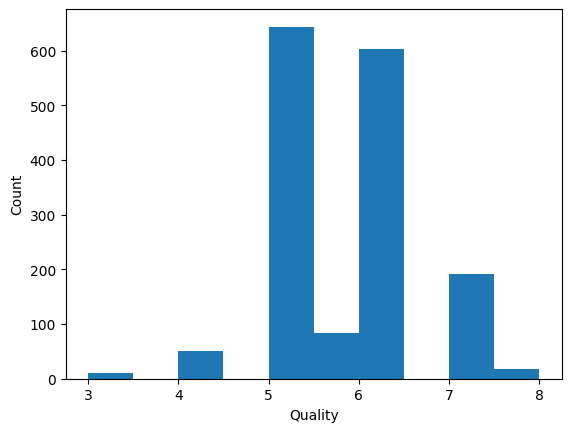

In [29]:
# Histogram of target parameter
plt.hist(df["quality"])
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

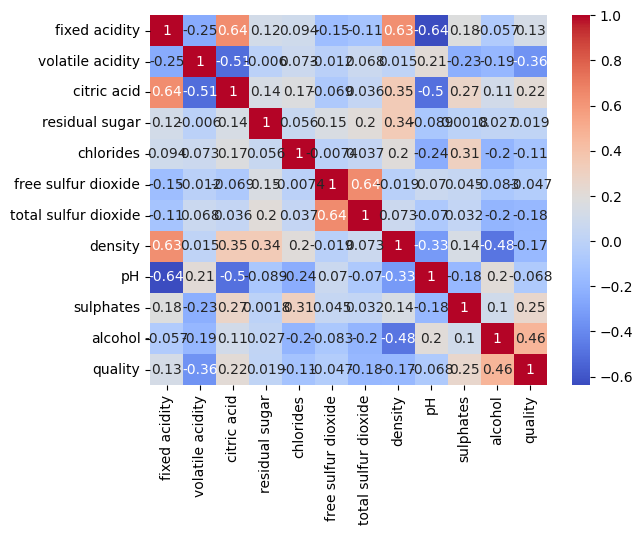

In [30]:
# Correlation heatmap between parameters
plt.title("Correlation Heatmap")
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

We can observe a positive correlation between these characteristics :
- fixed acidity et density
- fixed acidity et citric acid
- total sulfur dioxide et free sulfur dioxide

And negative correlations between:
- pH et fixed acidity
- pH et citric acid
- alcohol et density

In [22]:
# Create a scatter plot matrix
sns.pairplot(data=df, vars=["fixed acidity", "volatile acidity", "citric acid", "residual sugar",
"chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates",
"alcohol"], hue="quality")

Output hidden; open in https://colab.research.google.com to view.

## Perspectives

Linear regression is a model that could help us predict the target variable, especially for linear data. If the data form a diagonal with a positive slope then the characteristics are positively correlated; with a negative slope they are negatively correlated.